In [1]:
!wget -O dataset.7z "https://researchdata.gla.ac.uk/848/20/Dataset_848.7z"
!7z x dataset.7z -odata/raw

--2026-09-30 18:12:47--  https://researchdata.gla.ac.uk/848/20/Dataset_848.7z
Resolving researchdata.gla.ac.uk (researchdata.gla.ac.uk)... 130.209.34.138
Connecting to researchdata.gla.ac.uk (researchdata.gla.ac.uk)|130.209.34.138|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2060197481 (1.9G) [application/x-7z-compressed]
Saving to: ‘dataset.7z’

dataset.7z          100%[===================>]   1.92G  54.0MB/s    in 36s     

2026-09-30 18:13:24 (54.4 MB/s) - ‘dataset.7z’ saved [2060197481/2060197481]


7-Zip 23.01 (x64) : Copyright (c) 1999-2023 Igor Pavlov : 2023-06-20
 64-bit locale=en_US.UTF-8 Threads:2 OPEN_MAX:1048576

Scanning the drive for archives:
  0M Scan         1 file, 2060197481 bytes (1965 MiB)

Extracting archive: dataset.7z
--
Path = dataset.7z
Type = 7z
Physical Size = 2060197481
Headers Size = 17210
Method = LZMA2:26
Solid = +
Blocks = 5

  0%      0% 7        1% 7        2% 7      

In [7]:
import os

ruta = "data/raw"
for raiz, carpetas, ficheros in os.walk(ruta):
  print(raiz, len(ficheros), ficheros[:3])

data/raw 1 ['Document for all datasets - 03092019.pdf']
data/raw/3 June 2017 Dataset 162 ['6P32A06R3.dat', '1P29A01R3.dat', '4P34A04R3.dat']
data/raw/6 February 2019 NG Homes Dataset 301 ['1P29A01R3.dat', '4P34A04R3.dat', '1P28A01R1.dat']
data/raw/1 December 2017 Dataset 360 ['3P43A03R03.dat', '3P43A03R01.dat', '2P36A02R01.dat']
data/raw/4 July 2018 Dataset 288 ['5P58A05R1.dat', '4P72A04R3.dat', '6P68A06R1.dat']
data/raw/2 March 2017 Dataset 48 ['2P12A02R3.dat', '5P12A05R1.dat', '2P11A02R2.dat']
data/raw/7 March 2019 West Cumbria Dataset 289 ['4P49A04R1.dat', '5P37A05R3.dat', '3P41A03R2.dat']
data/raw/5 February 2019 UoG Dataset 306 ['6P06A06R01.dat', '6P16A06R02.dat', '6P10A06R02.dat']


In [3]:
with open("/content/data/raw/4 July 2018 Dataset/6P70A06R1.dat") as f:
    for i in range(len("/content/data/raw/4 July 2018 Dataset/6P70A06R1.dat")):
        print(f.readline().strip())

5800000000.000000
1.000000
128
400000000.000000
1599+2095i
2026+2082i
2046+2091i
2023+1487i
2205+1690i
2230+1759i
2247+1834i
2234+1939i
2178+2000i
2109+1990i
2088+1939i
2113+1938i
2121+1997i
2092+2009i
2083+1983i
2104+2026i
2034+2043i
2018+1998i
2025+1979i
2018+1977i
2019+1940i
2070+1950i
2089+2005i
2068+2071i
2031+2125i
1941+2099i
1880+2020i
1855+1946i
1855+1830i
1930+1711i
2039+1683i
2170+1749i
2267+1907i
2238+2084i
2174+2172i
2068+2190i
1961+2148i
1936+1973i
1992+1925i
2082+1978i
2085+2082i
2031+2107i
1974+2130i
1920+2046i
1913+1975i
1901+1936i
1945+1880i


In [4]:
with open("/content/data/raw/4 July 2018 Dataset/6P70A06R1.dat") as f:

  print(f.readline())


5800000000.000000



In [3]:
import numpy as np

def cargar_ruta(ruta):
  with open(ruta) as f:
      lineas = f.readlines()

      params = {
          "fc":   float(lineas[0]),
          "t_chirp":    float(lineas[1]),
          "n_muestras": int(lineas[2]),
          "bw":         float(lineas[3])
      }

      datos = []

      for complejo in lineas[4:]:
        complejo = complejo.strip()
        complejo = complejo.replace("i", "j")
        complejo = complex(complejo)
        datos.append(complejo)
      datos = np.array(datos)

  n = params["n_muestras"]
  assert len(datos) % n == 0, f"{ruta}: {len(datos)} datos, no es múltiplo de {n}"
  datos = datos.reshape((n, -1), order="F")

  return params, datos


In [8]:
%%time
RUTA = "/content/data/raw/4 July 2018 Dataset/6P70A06R1.dat"

params, datos = cargar_ruta(RUTA)
print(datos.dtype, datos.shape)

complex128 (128, 5000)
CPU times: user 738 ms, sys: 56.9 ms, total: 794 ms
Wall time: 813 ms


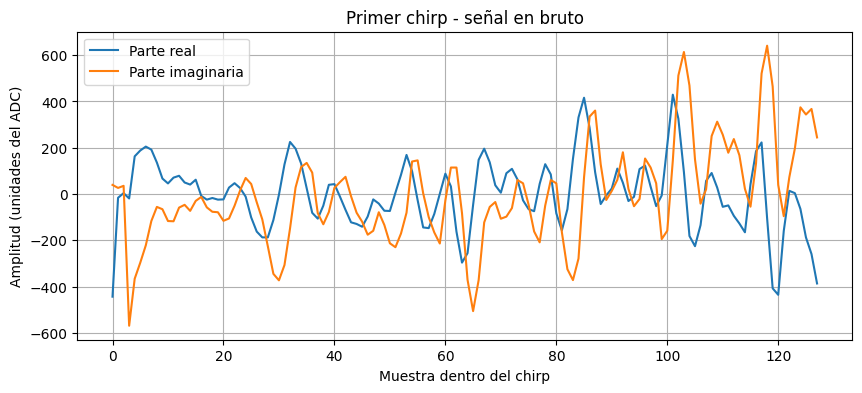

Media de todos los datos: (-9.822542779147625e-14-2.3283064365386963e-13j)


In [9]:
import matplotlib.pyplot as plt

chirp = datos[:, 0]

datos_sin_dc = datos - np.mean(datos)
chirp = datos_sin_dc[:, 0]

plt.figure(figsize=(10, 4))
plt.plot(chirp.real, label="Parte real")
plt.plot(chirp.imag, label="Parte imaginaria")
plt.xlabel("Muestra dentro del chirp")
plt.ylabel("Amplitud (unidades del ADC)")
plt.title("Primer chirp - señal en bruto")
plt.legend()
plt.grid(True)
plt.show()

print("Media de todos los datos:", np.mean(datos_sin_dc))

In [22]:
def resolucion_distancia(bw):
    return 3e8 / (2 * bw)

def fft_distancia(datos):
  return np.fft.fft(datos, axis=0)

def elim_offset(datos):
  return datos - np.mean(datos)

def filtro_mti(perfil):
  return perfil - np.mean(perfil, axis=1, keepdims=True)

def detectar_rango(perfil_mti, margen_db=10, salto=2):

  salto_der = salto_izq = True

  potencia = np.abs(perfil_mti) ** 2

  energia = np.sum(potencia, axis=1)
  energia_db = 10 * np.log10(energia)
  umbral = np.median(energia_db) + margen_db

  semilla = np.argmax(energia_db)

  izquierda = semilla
  derecha = semilla

  while izquierda - 1 >= 0 and (energia_db[izquierda - 1] > umbral or salto_izq):

    if energia_db[izquierda - 1] < umbral:
      salto_izq = False
      izquierda = max(0, izquierda - salto)
    else:
      izquierda -= 1


  while derecha + 1 < len(energia_db) and (energia_db[derecha + 1] > umbral or salto_der):

    if energia_db[derecha + 1] < umbral:
      salto_der = False
      derecha = min(len(energia_db) - 1, derecha + salto)
    else:
      derecha += 1

  return izquierda, derecha
def senal_temporal(perfil):
  return

[[-2.54010000e+01 -766.432j      -1.54010000e+01 -751.432j
  -2.54010000e+01 -762.432j      ...  1.75990000e+01 +147.568j
   1.85990000e+01 +163.568j      -2.40100000e+00 +117.568j     ]
 [-8.06360649e+03+7204.28684338j -8.05189085e+03+7199.36546399j
  -8.05637077e+03+7193.07025732j ... -8.25106468e+03+7109.37453546j
  -8.25581089e+03+7114.58437839j -8.23747559e+03+7094.22185588j]
 [-8.12776930e+03-5129.15996109j -8.12052110e+03-5139.4538903j
  -8.12534535e+03-5118.97733991j ... -7.23130395e+03-3676.48923236j
  -7.19628573e+03-3658.05150707j -7.20644323e+03-3665.88950744j]
 ...
 [ 1.98798661e+03+1822.98351893j  1.98169818e+03+1847.96412367j
   1.99472324e+03+1842.48592394j ...  6.96842067e+02+2292.93924502j
   6.40627738e+02+2285.88349384j  6.60949122e+02+2292.81077929j]
 [ 3.38709960e+03+1461.50815784j  3.38305832e+03+1461.60893077j
   3.39249844e+03+1477.79745265j ...  1.82110225e+03+2462.01501356j
   1.81396060e+03+2497.55484844j  1.82182363e+03+2473.31008276j]
 [ 5.42459977e+03+369

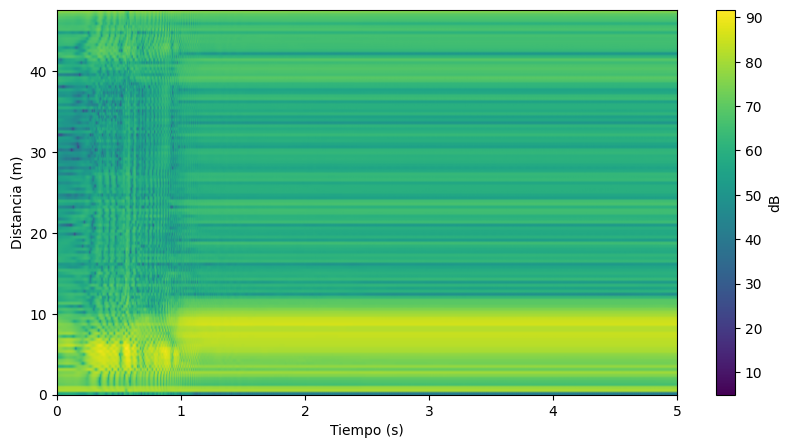

In [17]:
datos_sin_dc = elim_offset(datos)
perfil = fft_distancia(datos_sin_dc)

print(perfil)

res = resolucion_distancia(params["bw"])
eje_distancia = np.arange(perfil.shape[0]) * res

perfil_db = 20 * np.log10(np.abs(perfil))
t_max = perfil.shape[1] * params["t_chirp"] / 1000

plt.figure(figsize=(10, 5))
plt.imshow(perfil_db, aspect="auto", origin="lower",
           extent=[0, t_max, 0, eje_distancia[-1]])
plt.xlabel("Tiempo (s)")
plt.ylabel("Distancia (m)")
plt.colorbar(label="dB")
plt.show()

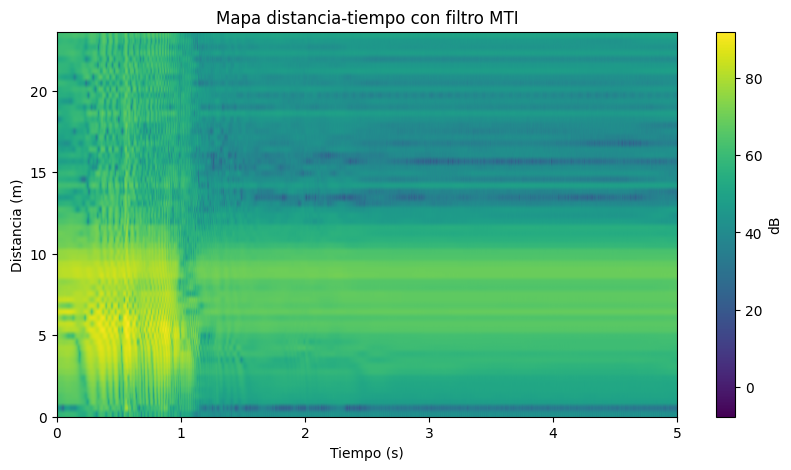

In [18]:
datos_sin_dc = elim_offset(datos)
perfil = fft_distancia(datos_sin_dc)
perfil = perfil[: perfil.shape[0] // 2]
perfil_mti = filtro_mti(perfil)

res = resolucion_distancia(params["bw"])
eje_distancia = np.arange(perfil_mti.shape[0]) * res
t_max = perfil_mti.shape[1] * params["t_chirp"] / 1000

perfil_db = 20 * np.log10(np.abs(perfil_mti))

plt.figure(figsize=(10, 5))
plt.imshow(perfil_db, aspect="auto", origin="lower",
           extent=[0, t_max, 0, eje_distancia[-1]])
plt.xlabel("Tiempo (s)")
plt.ylabel("Distancia (m)")
plt.colorbar(label="dB")
plt.title("Mapa distancia-tiempo con filtro MTI")
plt.show()

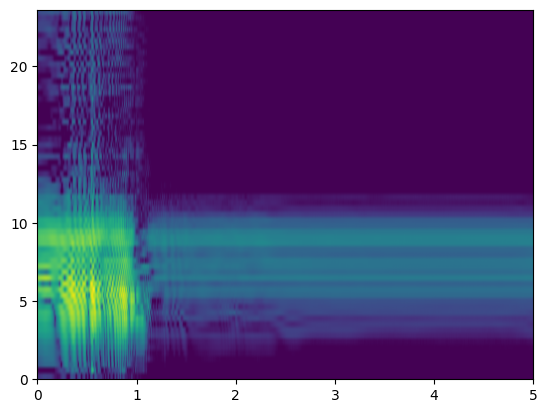

In [19]:
vmax = perfil_db.max()
plt.imshow(perfil_db, aspect="auto", origin="lower",
           extent=[0, t_max, 0, eje_distancia[-1]],
           vmin=vmax - 40, vmax=vmax)

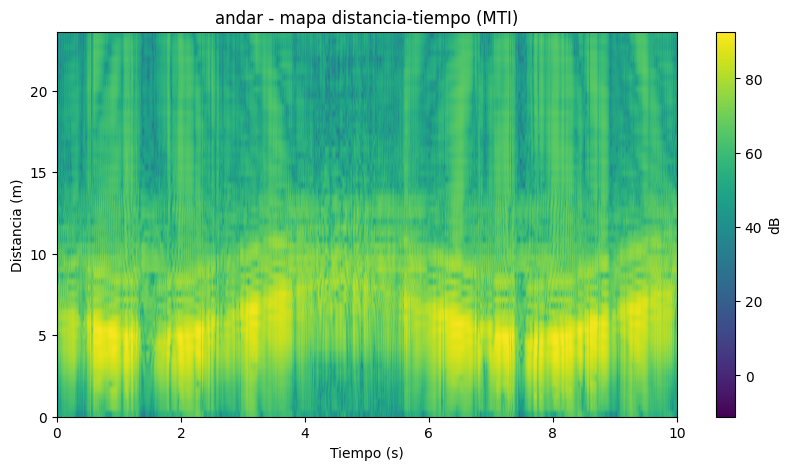

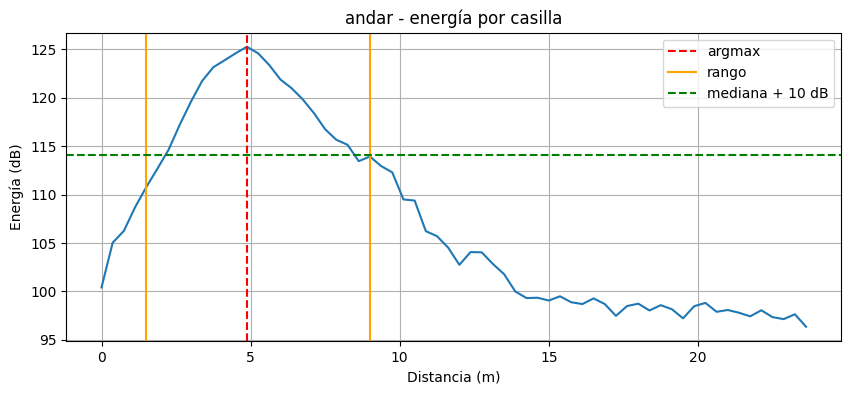

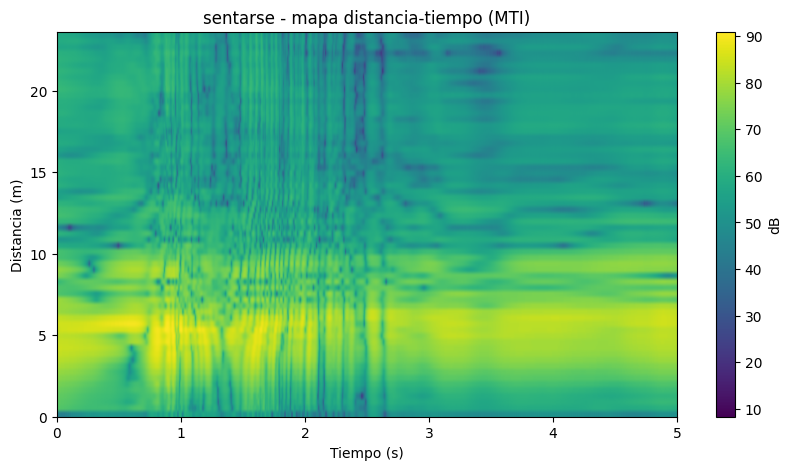

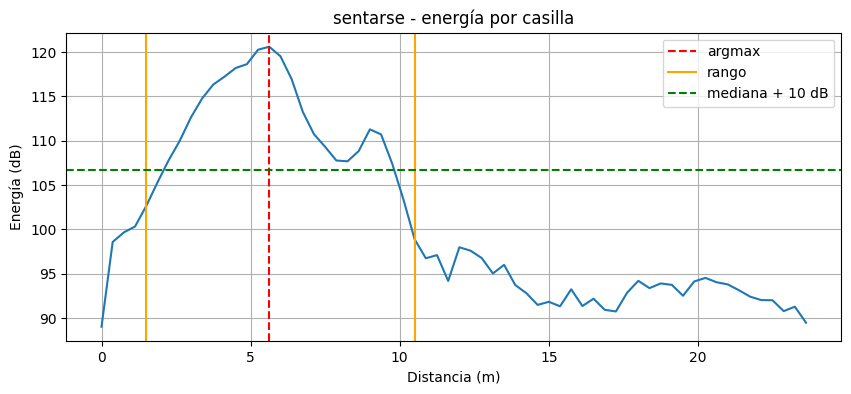

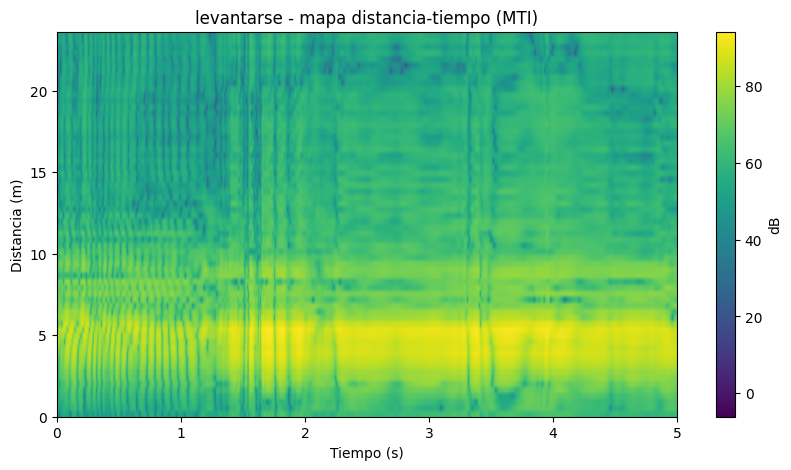

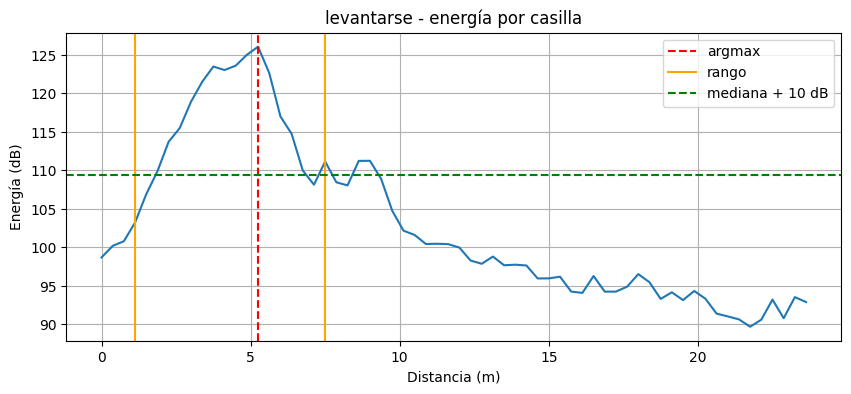

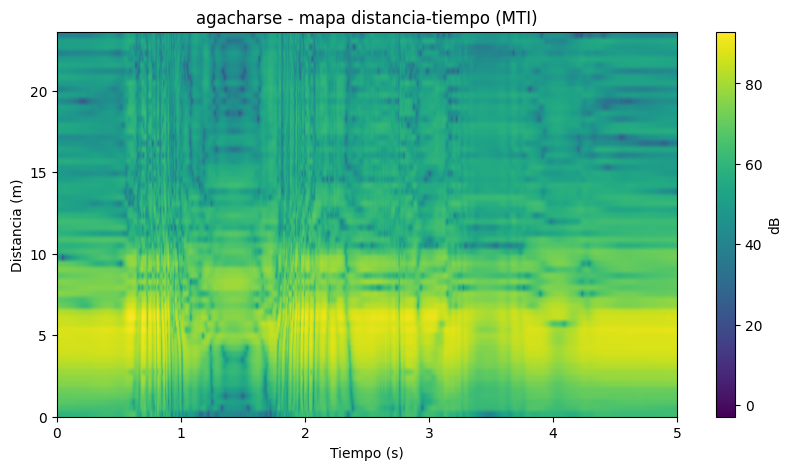

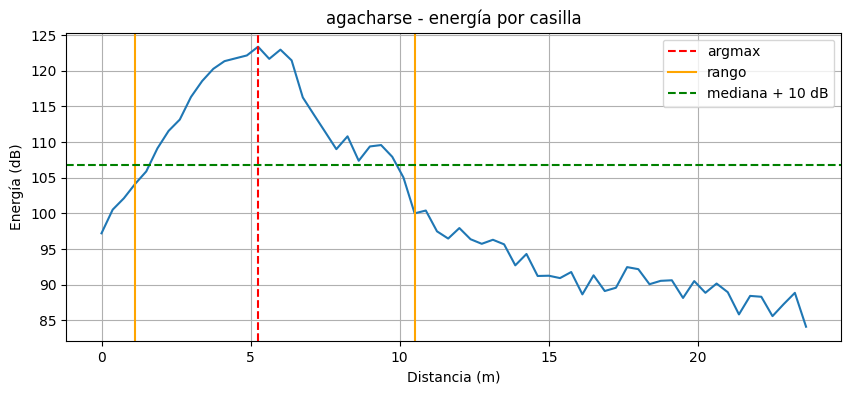

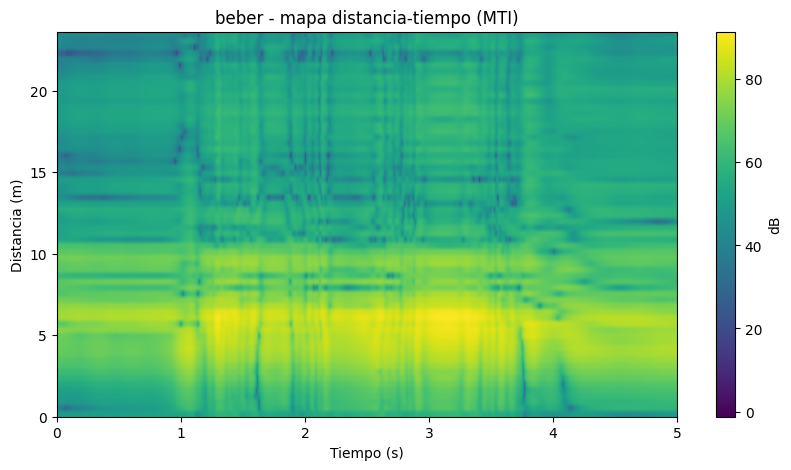

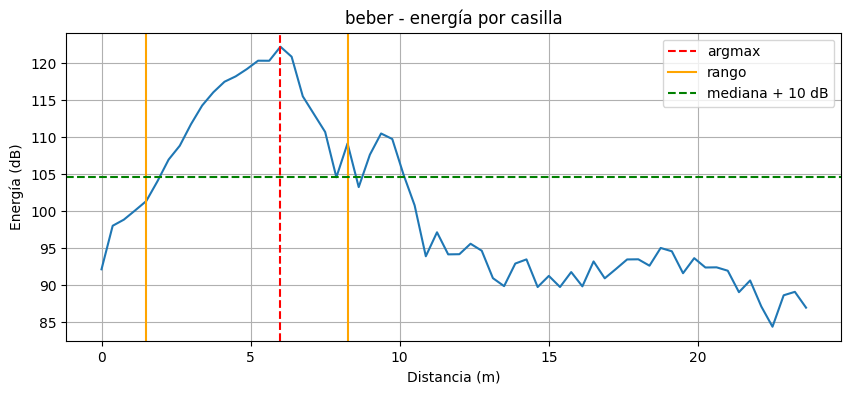

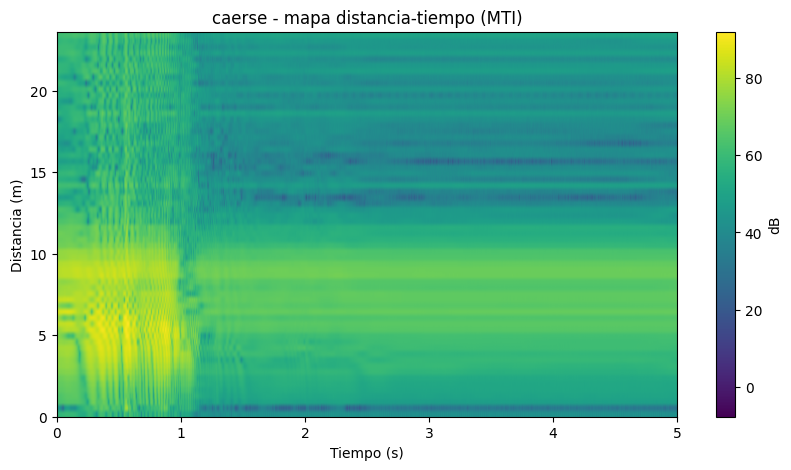

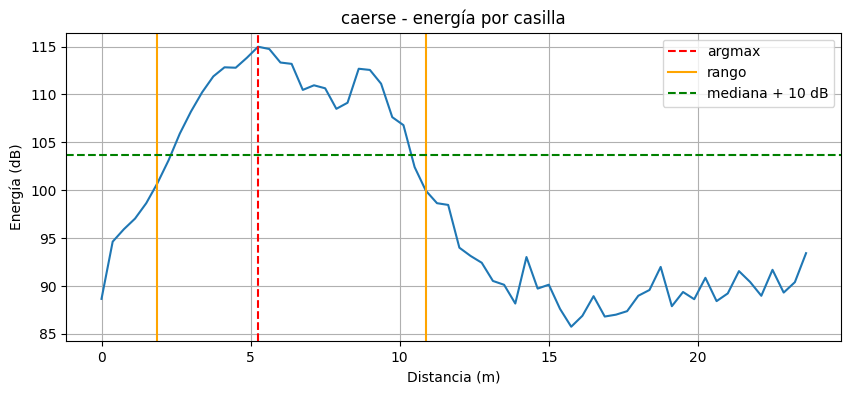

In [20]:
fich_andar = "/content/data/raw/1 December 2017 Dataset/1P45A01R03.dat"
fich_sentarse = "/content/data/raw/1 December 2017 Dataset/2P36A02R02.dat"
fich_levantarse ="/content/data/raw/1 December 2017 Dataset/3P41A03R02.dat"
fich_agacharse = "/content/data/raw/1 December 2017 Dataset/4P54A04R03.dat"
fich_beber = "/content/data/raw/1 December 2017 Dataset/5P52A05R03.dat"
fich_caerse = "/content/data/raw/4 July 2018 Dataset/6P70A06R1.dat"

ficheros = [(fich_andar, "andar"), (fich_sentarse, "sentarse"), (fich_levantarse, "levantarse"), (fich_agacharse, "agacharse"), (fich_beber, "beber"), (fich_caerse, "caerse")]

for fichero, actividad in ficheros:

  params, datos = cargar_ruta(fichero)

  datos_sin_dc = elim_offset(datos)
  perfil = fft_distancia(datos_sin_dc)
  perfil = perfil[: perfil.shape[0] // 2]
  perfil_mti = filtro_mti(perfil)

  res = resolucion_distancia(params["bw"])
  eje_distancia = np.arange(perfil_mti.shape[0]) * res
  t_max = perfil_mti.shape[1] * params["t_chirp"] / 1000

  perfil_db = 20 * np.log10(np.abs(perfil_mti))

  plt.figure(figsize=(10, 5))
  plt.imshow(perfil_db, aspect="auto", origin="lower",
            extent=[0, t_max, 0, eje_distancia[-1]])
  plt.xlabel("Tiempo (s)")
  plt.ylabel("Distancia (m)")
  plt.colorbar(label="dB")
  plt.title(f"{actividad} - mapa distancia-tiempo (MTI)")
  plt.show()

  potencia = np.abs(perfil_mti) ** 2
  energia = np.sum(potencia, axis=1)
  energia_db = 10 * np.log10(energia)

  casilla_pico = np.argmax(energia_db)
  umbral = np.median(energia_db) + 10

  casilla_min, casilla_max = detectar_rango(perfil_mti)

  plt.figure(figsize=(10, 4))
  plt.plot(eje_distancia, energia_db)
  plt.axvline(casilla_pico * res, color="red", linestyle="--", label="argmax")
  plt.axvline(casilla_min * res, color="orange", label="rango")
  plt.axvline(casilla_max * res, color="orange")
  plt.axhline(umbral, color="green", linestyle="--", label="mediana + 10 dB")
  plt.xlabel("Distancia (m)"); plt.ylabel("Energía (dB)")
  plt.title(f"{actividad} - energía por casilla")
  plt.legend(); plt.grid(True); plt.show()


In [21]:
casilla_min, casilla_max = detectar_rango(perfil_mti)
print(casilla_min, casilla_max)
print(casilla_min * res, "m -", casilla_max * res, "m")

5 29
1.875 m - 10.875 m
